<a href="https://colab.research.google.com/github/germfsip/Agentes-Inteligentes-2026/blob/main/Unir_AI_Sesion4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 4 — Word Vectors

**Asignatura:** Sistemas Cognitivos Artificiales — Maestría UNIR México  
**Profesor:** Gerardo A. Martínez Fernández  
**Tema 6:** Word Vectors

---

## Objetivos de esta práctica

1. Entender la diferencia entre representaciones discretas y distribuidas
2. Entrenar Word2Vec desde cero con Gensim
3. Explorar embeddings preentrenados (Google News)
4. Visualizar clusters y aritmética vectorial


## Parte 1: Setup e intuición

In [1]:
!pip install gensim -q
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim
from gensim.models import Word2Vec
print(f'Gensim: {gensim.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 15.8 MB/s eta 0:00:00
Gensim: 4.4.0


### El problema de las representaciones discretas
Veamos por qué one-hot encoding no captura similitud.

In [2]:
# Vocabulario pequeño de ejemplo
vocab = ['hotel', 'motel', 'restaurante', 'pizza', 'playa']

# One-hot encoding
print('=== One-Hot Encoding ===')
for i, w in enumerate(vocab):
    vec = [0] * len(vocab)
    vec[i] = 1
    print(f'  {w:>12} → {vec}')

# Similitud coseno entre hotel y motel
from numpy.linalg import norm
hotel_oh = np.array([1,0,0,0,0])
motel_oh = np.array([0,1,0,0,0])
cosine = np.dot(hotel_oh, motel_oh) / (norm(hotel_oh) * norm(motel_oh))
print(f'\n📊 Similitud coseno (hotel, motel) en one-hot: {cosine:.1f}')
print('   → ¡Cero! No hay forma de capturar que son casi sinónimos.')

=== One-Hot Encoding ===
         hotel → [1, 0, 0, 0, 0]
         motel → [0, 1, 0, 0, 0]
   restaurante → [0, 0, 1, 0, 0]
         pizza → [0, 0, 0, 1, 0]
         playa → [0, 0, 0, 0, 1]

📊 Similitud coseno (hotel, motel) en one-hot: 0.0
   → ¡Cero! No hay forma de capturar que son casi sinónimos.


## Parte 2: Entrenar Word2Vec desde cero
Usamos un corpus simple para entender el mecanismo.

In [3]:
# Corpus de ejemplo: oraciones sobre viajes y comida
corpus = [
    'el hotel está cerca de la playa'.split(),
    'el motel está cerca del centro'.split(),
    'reservé un hotel para las vacaciones'.split(),
    'el motel es más económico que el hotel'.split(),
    'la playa está hermosa en verano'.split(),
    'el restaurante del hotel tiene buena comida'.split(),
    'pedimos pizza en el restaurante'.split(),
    'la pizza del restaurante estaba deliciosa'.split(),
    'fuimos a la playa después del almuerzo'.split(),
    'el hotel tiene vista al mar'.split(),
    'el mar está tranquilo cerca de la playa'.split(),
    'cenamos pizza cerca del motel'.split(),
    'las vacaciones en la playa fueron increíbles'.split(),
    'el restaurante cerca del mar es excelente'.split(),
    'la comida del hotel incluye desayuno'.split(),
]

print(f'Oraciones: {len(corpus)}')
print(f'Ejemplo: {corpus[0]}')

Oraciones: 15
Ejemplo: ['el', 'hotel', 'está', 'cerca', 'de', 'la', 'playa']


In [4]:
# Entrenar Word2Vec con Skip-gram
modelo_sg = Word2Vec(
    sentences=corpus,
    vector_size=50,       # Dimensión de los vectores
    window=3,             # Tamaño de la ventana de contexto
    min_count=1,          # Incluir todas las palabras
    sg=1,                 # 1 = Skip-gram, 0 = CBOW
    epochs=200,           # Más épocas porque el corpus es pequeño
    seed=42
)

print(f'Vocabulario: {len(modelo_sg.wv)} palabras')
print(f'Dimensión de los vectores: {modelo_sg.wv.vector_size}')

Vocabulario: 44 palabras
Dimensión de los vectores: 50


In [5]:
# Explorar el vector de una palabra
print('Vector de "hotel" (primeros 10 valores):')
print(np.round(modelo_sg.wv['hotel'][:10], 3))

# Similitudes
print('\n📊 Palabras más similares a "hotel":')
for word, sim in modelo_sg.wv.most_similar('hotel', topn=5):
    print(f'  {word:>15}: {sim:.4f}')

print('\n📊 Palabras más similares a "playa":')
for word, sim in modelo_sg.wv.most_similar('playa', topn=5):
    print(f'  {word:>15}: {sim:.4f}')

Vector de "hotel" (primeros 10 valores):
[ 0.057 -0.068 -0.023 -0.012  0.036 -0.044 -0.042  0.009 -0.068  0.055]

📊 Palabras más similares a "hotel":
               la: 0.9819
              del: 0.9814
               el: 0.9686
            playa: 0.9680
           comida: 0.9659

📊 Palabras más similares a "playa":
               la: 0.9788
              del: 0.9722
            hotel: 0.9680
               el: 0.9678
            cerca: 0.9635


In [6]:
# Similitud entre pares específicos
pares = [('hotel','motel'), ('hotel','pizza'), ('playa','mar'),
         ('restaurante','comida'), ('hotel','playa')]

print('📊 Similitudes entre pares:')
for w1, w2 in pares:
    sim = modelo_sg.wv.similarity(w1, w2)
    bar = '█' * int(max(0, sim) * 30)
    print(f'  ({w1}, {w2}): {sim:+.4f}  {bar}')

📊 Similitudes entre pares:
  (hotel, motel): +0.9283  ███████████████████████████
  (hotel, pizza): +0.9212  ███████████████████████████
  (playa, mar): +0.9252  ███████████████████████████
  (restaurante, comida): +0.9093  ███████████████████████████
  (hotel, playa): +0.9680  █████████████████████████████


### Skip-gram vs CBOW

In [7]:
# Entrenar CBOW para comparar
modelo_cbow = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=3,
    min_count=1,
    sg=0,                 # 0 = CBOW
    epochs=200,
    seed=42
)

# Comparar similitudes
print('📊 Comparación Skip-gram vs CBOW:')
print(f'{"Par":<25} {"Skip-gram":>10} {"CBOW":>10}')
print('-' * 47)
for w1, w2 in pares:
    sim_sg = modelo_sg.wv.similarity(w1, w2)
    sim_cb = modelo_cbow.wv.similarity(w1, w2)
    print(f'  ({w1}, {w2}){" "*(18-len(w1)-len(w2))} {sim_sg:>+.4f} {sim_cb:>+.4f}')

📊 Comparación Skip-gram vs CBOW:
Par                        Skip-gram       CBOW
-----------------------------------------------
  (hotel, motel)         +0.9283 +0.7550
  (hotel, pizza)         +0.9212 +0.6998
  (playa, mar)           +0.9252 +0.6946
  (restaurante, comida)  +0.9093 +0.7407
  (hotel, playa)         +0.9680 +0.8830


## Parte 3: Embeddings preentrenados
Usamos los embeddings de Google News (3M palabras, entrenados en ~100B palabras).

In [8]:
# Descargar embeddings preentrenados (puede tardar ~1 minuto)
import gensim.downloader as api

print('Descargando word2vec-google-news-300...')
print('(~1.6 GB comprimido, puede tardar unos minutos)')
wv_pretrained = api.load('word2vec-google-news-300')
print(f'\n✓ Cargado: {len(wv_pretrained)} palabras, {wv_pretrained.vector_size} dimensiones')

Descargando word2vec-google-news-300...
(~1.6 GB comprimido, puede tardar unos minutos)
[==================================================] 100.0% 1662.8/1662.8MB downloaded

✓ Cargado: 3000000 palabras, 300 dimensiones


In [9]:
# Similitudes con embeddings de alta calidad
print('📊 Similitudes con Google News embeddings:\n')

pares_pro = [
    ('hotel', 'motel'), ('hotel', 'pizza'), ('king', 'queen'),
    ('dog', 'cat'), ('car', 'automobile'), ('happy', 'sad'),
    ('python', 'java'), ('Madrid', 'Spain'),
]

for w1, w2 in pares_pro:
    try:
        sim = wv_pretrained.similarity(w1, w2)
        bar = '█' * int(max(0, sim) * 40)
        print(f'  ({w1}, {w2}){" "*(25-len(w1)-len(w2))} {sim:+.4f}  {bar}')
    except KeyError as e:
        print(f'  {e} no está en el vocabulario')

📊 Similitudes con Google News embeddings:

  (hotel, motel)                +0.6617  ██████████████████████████
  (hotel, pizza)                +0.2010  ████████
  (king, queen)                 +0.6511  ██████████████████████████
  (dog, cat)                    +0.7609  ██████████████████████████████
  (car, automobile)             +0.5838  ███████████████████████
  (happy, sad)                  +0.5355  █████████████████████
  (python, java)                +0.1254  █████
  (Madrid, Spain)               +0.6743  ██████████████████████████


### Aritmética vectorial
El resultado más famoso de Word2Vec: king − man + woman ≈ queen

In [10]:
# Aritmética vectorial
def analogia(positivo, negativo, modelo, topn=3):
    """Resuelve: positivo[0] - negativo[0] + positivo[1] ≈ ?"""
    try:
        resultados = modelo.most_similar(positive=positivo, negative=negativo, topn=topn)
        return resultados
    except KeyError as e:
        return [(str(e), 0.0)]

# Ejemplos clásicos
analogias = [
    (['king', 'woman'], ['man'], 'king − man + woman'),
    (['Madrid', 'France'], ['Spain'], 'Madrid − Spain + France'),
    (['bigger', 'small'], ['big'], 'bigger − big + small'),
    (['walking', 'swim'], ['walk'], 'walking − walk + swim'),
    (['Japan', 'Italian'], ['Japanese'], 'Japan − Japanese + Italian'),
]

print('📊 Aritmética de word vectors:\n')
for pos, neg, desc in analogias:
    results = analogia(pos, neg, wv_pretrained)
    top = results[0]
    print(f'  {desc}')
    print(f'    → {top[0]} ({top[1]:.4f})')
    print()

📊 Aritmética de word vectors:

  king − man + woman
    → queen (0.7118)

  Madrid − Spain + France
    → Paris (0.7502)

  bigger − big + small
    → larger (0.7402)

  walking − walk + swim
    → swimming (0.8246)

  Japan − Japanese + Italian
    → Italy (0.8690)



## Parte 4: Visualización con t-SNE

In [11]:
# Seleccionar palabras para visualizar
grupos = {
    'Países': ['Spain', 'France', 'Germany', 'Italy', 'Japan', 'China', 'Mexico', 'Brazil'],
    'Capitales': ['Madrid', 'Paris', 'Berlin', 'Rome', 'Tokyo', 'Beijing', 'Mexico_City'],
    'Tecnología': ['Google', 'Apple', 'Microsoft', 'Amazon', 'Samsung', 'Intel', 'IBM'],
    'Animales': ['dog', 'cat', 'horse', 'elephant', 'tiger', 'lion', 'bird'],
    'Comida': ['pizza', 'sushi', 'hamburger', 'pasta', 'chocolate', 'coffee', 'tea'],
}

# Obtener vectores
palabras_todas = []
vectores = []
colores_mapa = []
colores_grupo = {'Países':'#0098CD', 'Capitales':'#E8792F', 'Tecnología':'#2E8B57',
                 'Animales':'#6D28D9', 'Comida':'#C0392B'}

for grupo, palabras in grupos.items():
    for p in palabras:
        if p in wv_pretrained:
            palabras_todas.append(p)
            vectores.append(wv_pretrained[p])
            colores_mapa.append(colores_grupo[grupo])

vectores = np.array(vectores)
print(f'Palabras a visualizar: {len(palabras_todas)}')

Palabras a visualizar: 35


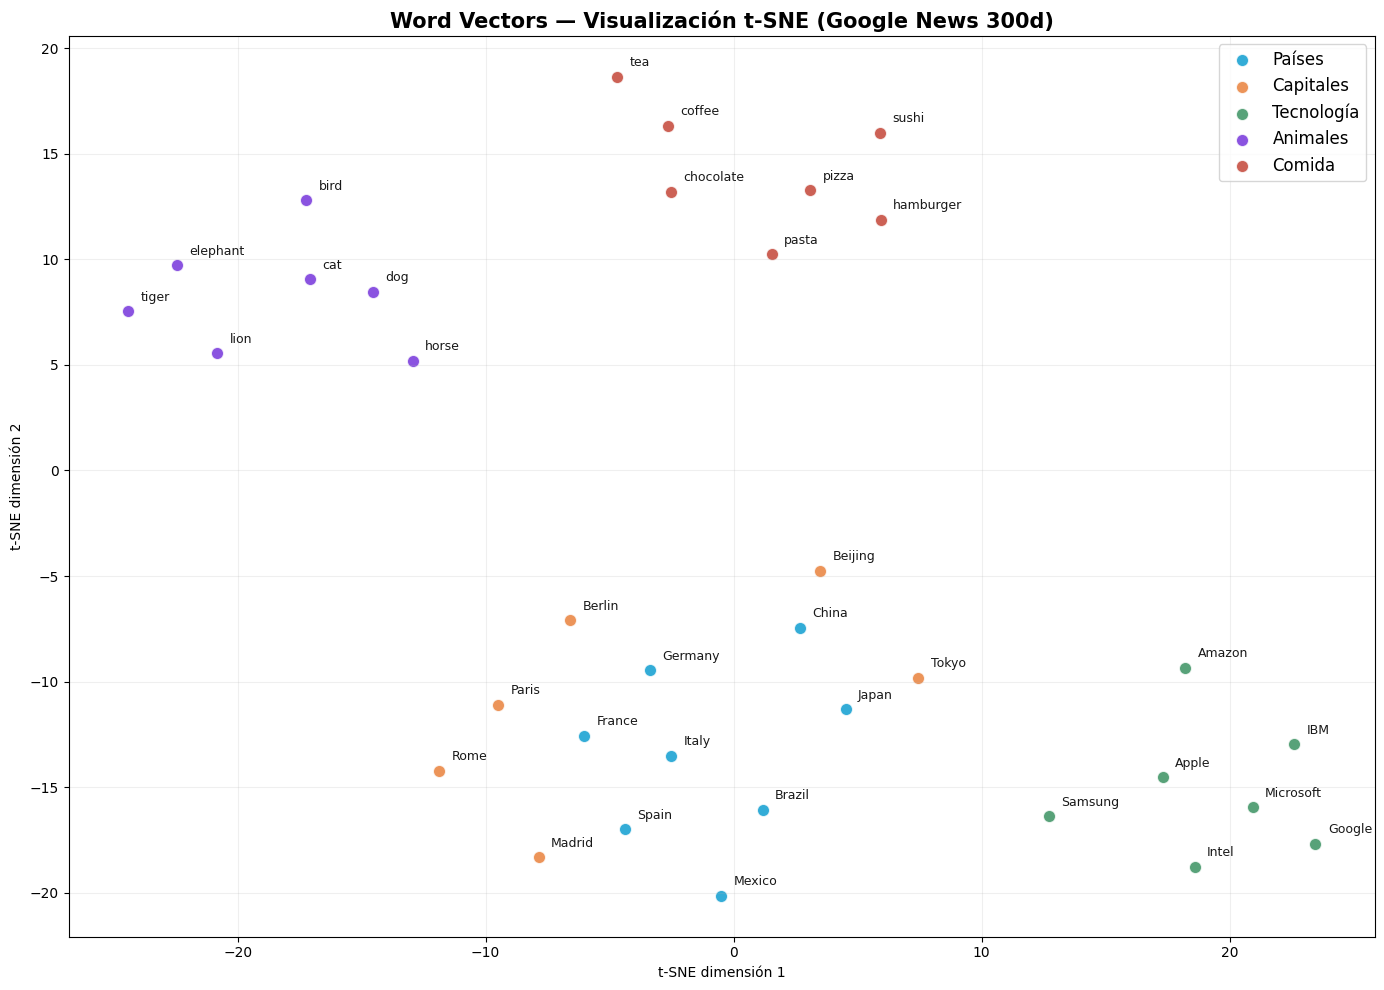

Observa cómo los clusters semánticos emergen naturalmente.


In [12]:
# Reducir a 2D con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(10, len(vectores)-1))
vecs_2d = tsne.fit_transform(vectores)

# Graficar
fig, ax = plt.subplots(figsize=(14, 10))

for grupo, color in colores_grupo.items():
    idxs = [i for i, p in enumerate(palabras_todas)
            if p in grupos.get(grupo, [])]
    if idxs:
        ax.scatter(vecs_2d[idxs, 0], vecs_2d[idxs, 1],
                   c=color, s=80, label=grupo, alpha=0.8, edgecolors='white')

for i, word in enumerate(palabras_todas):
    ax.annotate(word, (vecs_2d[i,0]+0.5, vecs_2d[i,1]+0.5),
                fontsize=9, alpha=0.9)

ax.legend(fontsize=12, loc='best')
ax.set_title('Word Vectors — Visualización t-SNE (Google News 300d)',
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.set_xlabel('t-SNE dimensión 1')
ax.set_ylabel('t-SNE dimensión 2')
plt.tight_layout()
plt.show()

print('Observa cómo los clusters semánticos emergen naturalmente.')

## Parte 5: Impacto del tamaño de ventana

In [13]:
# Experimentar con diferentes tamaños de ventana
print('📊 Efecto del tamaño de ventana (window):\n')
print(f'{"Window":>8} {"sim(hotel,motel)":>18} {"sim(hotel,pizza)":>18}')
print('-' * 48)

for w in [1, 2, 3, 5, 8]:
    m = Word2Vec(sentences=corpus, vector_size=50, window=w,
                 min_count=1, sg=1, epochs=200, seed=42)
    s1 = m.wv.similarity('hotel', 'motel')
    s2 = m.wv.similarity('hotel', 'pizza')
    print(f'{w:>8} {s1:>+18.4f} {s2:>+18.4f}')

print('\nVentanas más grandes capturan relaciones más amplias (temáticas).')
print('Ventanas más pequeñas capturan relaciones más locales (sintácticas).')

📊 Efecto del tamaño de ventana (window):

  Window   sim(hotel,motel)   sim(hotel,pizza)
------------------------------------------------
       1            +0.6741            +0.8370
       2            +0.8100            +0.8920
       3            +0.9283            +0.9212
       5            +0.9555            +0.9599
       8            +0.9313            +0.9575

Ventanas más grandes capturan relaciones más amplias (temáticas).
Ventanas más pequeñas capturan relaciones más locales (sintácticas).


## 🏋️ Ejercicios propuestos

1. **Más analogías:** Prueba 5 analogías propias con los embeddings de Google News. ¿Cuántas funcionan correctamente?
2. **Corpus propio:** Descarga un corpus en español (Wikipedia dump) y entrena word2vec con Gensim. ¿Cómo se comparan los embeddings en español?
3. **Vector size:** Entrena modelos con vector_size = 10, 50, 100, 200 sobre el corpus de ejemplo. ¿Cómo cambian las similitudes?
4. **Palabras OOV:** ¿Qué pasa cuando una palabra no está en el vocabulario? Investiga FastText como alternativa que maneja subwords.

---

**Nota:** Los embeddings de Google News están en inglés. Para español, se pueden descargar desde [fasttext.cc](https://fasttext.cc/docs/en/crawl-vectors.html).